In [7]:
# ==============================================================================
# CELLULE 6 : PRÉVISIONS FINANCIÈRES DAILY (GDELT T -> RENDEMENT T+1)
# ==============================================================================
import pandas as pd
from pathlib import Path
import yfinance as yf
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# --- FONCTION DE STATIONNARISATION ---
def strict_stationarize_daily(df):
    """Test ADF -> Différence si non-stationnaire (p >= 0.05)."""
    df_stat = df.copy()
    for col in df_stat.columns:
        valid_data = df_stat[col].dropna()
        if len(valid_data) > 10:
            if adfuller(valid_data, autolag='AIC')[1] >= 0.05:
                df_stat[col] = df_stat[col].diff()
    return df_stat.dropna()

# ==============================================================================
# 1. CHARGEMENT DES DONNÉES GDELT (DAILY)
# ==============================================================================
start_date = pd.to_datetime('2015-03-02')
dir_geo = Path("data/indicators_geo_daily")

if dir_geo.exists():
    files_geo = list(dir_geo.glob("*.parquet"))
    df_geo_daily = pd.concat([pd.read_parquet(f) for f in files_geo], ignore_index=True)
    df_geo_daily = df_geo_daily.groupby(['period', 'region_key']).max().reset_index()
    df_geo_daily['period'] = pd.to_datetime(df_geo_daily['period'])
    df_geo_daily = df_geo_daily[df_geo_daily['period'] >= start_date].sort_values(['period', 'region_key'])
    print(f"✓ Base GDELT DAILY chargée : {len(df_geo_daily):,} lignes")
    print(f"  Régions : {list(df_geo_daily['region_key'].unique())}")
else:
    raise FileNotFoundError(f"⚠ Dossier {dir_geo} introuvable.")

# ==============================================================================
# 2. CONFIGURATION DES ACTIFS FINANCIERS ET DES MOTS-CLÉS GDELT CIBLES
# ==============================================================================
FINANCIAL_TARGETS = {
    'BRENT_CRUDE_OIL': {
        'ticker': 'BZ=F', 
        'region': 'US', # Le pétrole est pricé en USD, on observe le sentiment US/Global
        'keywords': ['energy_fossil', 'commodities_market_prices', 'energy_risks', 'conflict_war']
    },
    'BNP_PARIBAS (Banque FR)': {
        'ticker': 'BNP.PA', 
        'region': 'France',
        'keywords': ['finance_banks', 'finance_systemic_risk', 'finance_central_banks', 'finance_credit']
    },
    'LOCKHEED_MARTIN (Défense US)': {
        'ticker': 'LMT', 
        'region': 'US',
        'keywords': ['conflict_weapons', 'conflict_terrorism', 'conflict_war', 'industry_supply_chains']
    }
}

# ==============================================================================
# 3. EXÉCUTION DES MODÈLES (BOUCLE)
# ==============================================================================
for target_name, config in FINANCIAL_TARGETS.items():
    print(f"\n{'='*70}\n PRÉVISION À T+1 : {target_name} ({config['ticker']})\n{'='*70}")
    
    # A. Filtrage des données GDELT pour la région cible
    df_region = df_geo_daily[df_geo_daily['region_key'] == config['region']].set_index('period')
    
    # B. Sélection des colonnes GDELT via les mots-clés (On se limite aux poids de sentiment binaires pour éviter la multicolinéarité)
    target_cols = [c for c in df_region.columns if any(kw in c for kw in config['keywords']) and c.startswith('sent_bin_weight_')]
    X_gdelt = df_region[target_cols].copy()
    
    if X_gdelt.empty:
        print(f"⚠ Aucune variable GDELT correspondante trouvée.")
        continue

    # C. Ré-échantillonnage en Business Days (Lundi-Vendredi) et Stationnarisation
    X_gdelt_bday = X_gdelt.resample('B').mean().ffill() # Le sentiment du WE bascule sur le Lundi
    X_stat = strict_stationarize_daily(X_gdelt_bday)

    # D. Téléchargement des données de marché Daily (Yahoo Finance)
    try:
        # Utilisation de yf.Ticker().history() qui est beaucoup plus stable que yf.download()
        stock = yf.Ticker(config['ticker'])
        y_data = stock.history(start=start_date.strftime('%Y-%m-%d'), end="2026-07-01", interval="1d")['Close']
        
        if y_data.empty:
            print(f"⚠ Aucune donnée de marché trouvée pour {config['ticker']}.")
            continue
            
        # Nettoyage du fuseau horaire (YFinance renvoie souvent des dates 'timezone-aware')
        if y_data.index.tz is not None:
            y_data.index = y_data.index.tz_localize(None)
            
        y_returns = y_data.pct_change().dropna() * 100 # Rendement Daily en %
        
    except Exception as e:
        print(f"⚠ Erreur YFinance : {e}")
        continue

    # E. ALIGNEMENT PRÉDICTIF : X(t) prédit y(t+1)
# Remplace cette ligne :
    # y_target = y_returns.shift(-1).dropna()
    
    # Par celle-ci (Valeur absolue = Volatilité) :
    # E. ALIGNEMENT PRÉDICTIF ARX : GDELT(t) + Vol(t) prédisent Vol(t+1)
    
    # 1. La cible : Volatilité à T+1
    y_target = y_returns.abs().shift(-1).dropna()
    y_target.name = 'Future_Volatility_T1'
    
    # 2. Le terme Auto-Régressif : Volatilité à T
    y_lag = y_returns.abs()
    y_lag.name = 'AR1_Volatility_T'
    
    # 3. Fusion des features (GDELT + AR1)
    X_combined = X_stat.join(y_lag, how='inner')
    
    # 4. Alignement final avec la cible
    X_aligned, y_aligned = X_combined.align(y_target, join='inner', axis=0)
    
    # Standardisation
    X_scaled = pd.DataFrame(StandardScaler().fit_transform(X_aligned), columns=X_aligned.columns, index=X_aligned.index)
    X_scaled = sm.add_constant(X_scaled)

    # F. Modélisation OLS
    model = sm.OLS(y_aligned, X_scaled).fit()
    significant_vars = model.pvalues[model.pvalues < 0.10]
    
    print(f"Observations (N) : {len(y_aligned)}")
    print(f"R-squared global : {model.rsquared:.5f} | R-squared ajusté : {model.rsquared_adj:.5f}")
    print(f"\nSignaux GDELT prédictifs (p < 0.10) pour le rendement boursier du LENDEMAIN :")
    
    if len(significant_vars) > 1:
        for var, pval in significant_vars.items():
            if var != 'const':
                coef = model.params[var]
                direction = "Positif ↗" if coef > 0 else "Négatif ↘"
                print(f"  - {var.replace('sent_bin_weight_', '')} : Coef = {coef:.5f} ({direction}) | p = {pval:.5f}")
    else:
        print("  Aucun signal GDELT statistiquement significatif pour le lendemain.")

✓ Base GDELT DAILY chargée : 12,333 lignes
  Régions : ['France', 'UK', 'US']

 PRÉVISION À T+1 : BRENT_CRUDE_OIL (BZ=F)
Observations (N) : 2843
R-squared global : 0.09856 | R-squared ajusté : 0.09697

Signaux GDELT prédictifs (p < 0.10) pour le rendement boursier du LENDEMAIN :
  - commodities_market_prices : Coef = -0.21414 (Négatif ↘) | p = 0.00000
  - conflict_war : Coef = -0.17137 (Négatif ↘) | p = 0.00000
  - AR1_Volatility_T : Coef = 0.43605 (Positif ↗) | p = 0.00000

 PRÉVISION À T+1 : BNP_PARIBAS (Banque FR) (BNP.PA)
Observations (N) : 2892
R-squared global : 0.08305 | R-squared ajusté : 0.08146

Signaux GDELT prédictifs (p < 0.10) pour le rendement boursier du LENDEMAIN :
  - finance_banks : Coef = -0.09264 (Négatif ↘) | p = 0.01551
  - finance_central_banks : Coef = -0.12994 (Négatif ↘) | p = 0.00037
  - finance_systemic_risk : Coef = -0.05972 (Négatif ↘) | p = 0.02774
  - AR1_Volatility_T : Coef = 0.29079 (Positif ↗) | p = 0.00000

 PRÉVISION À T+1 : LOCKHEED_MARTIN (Défens

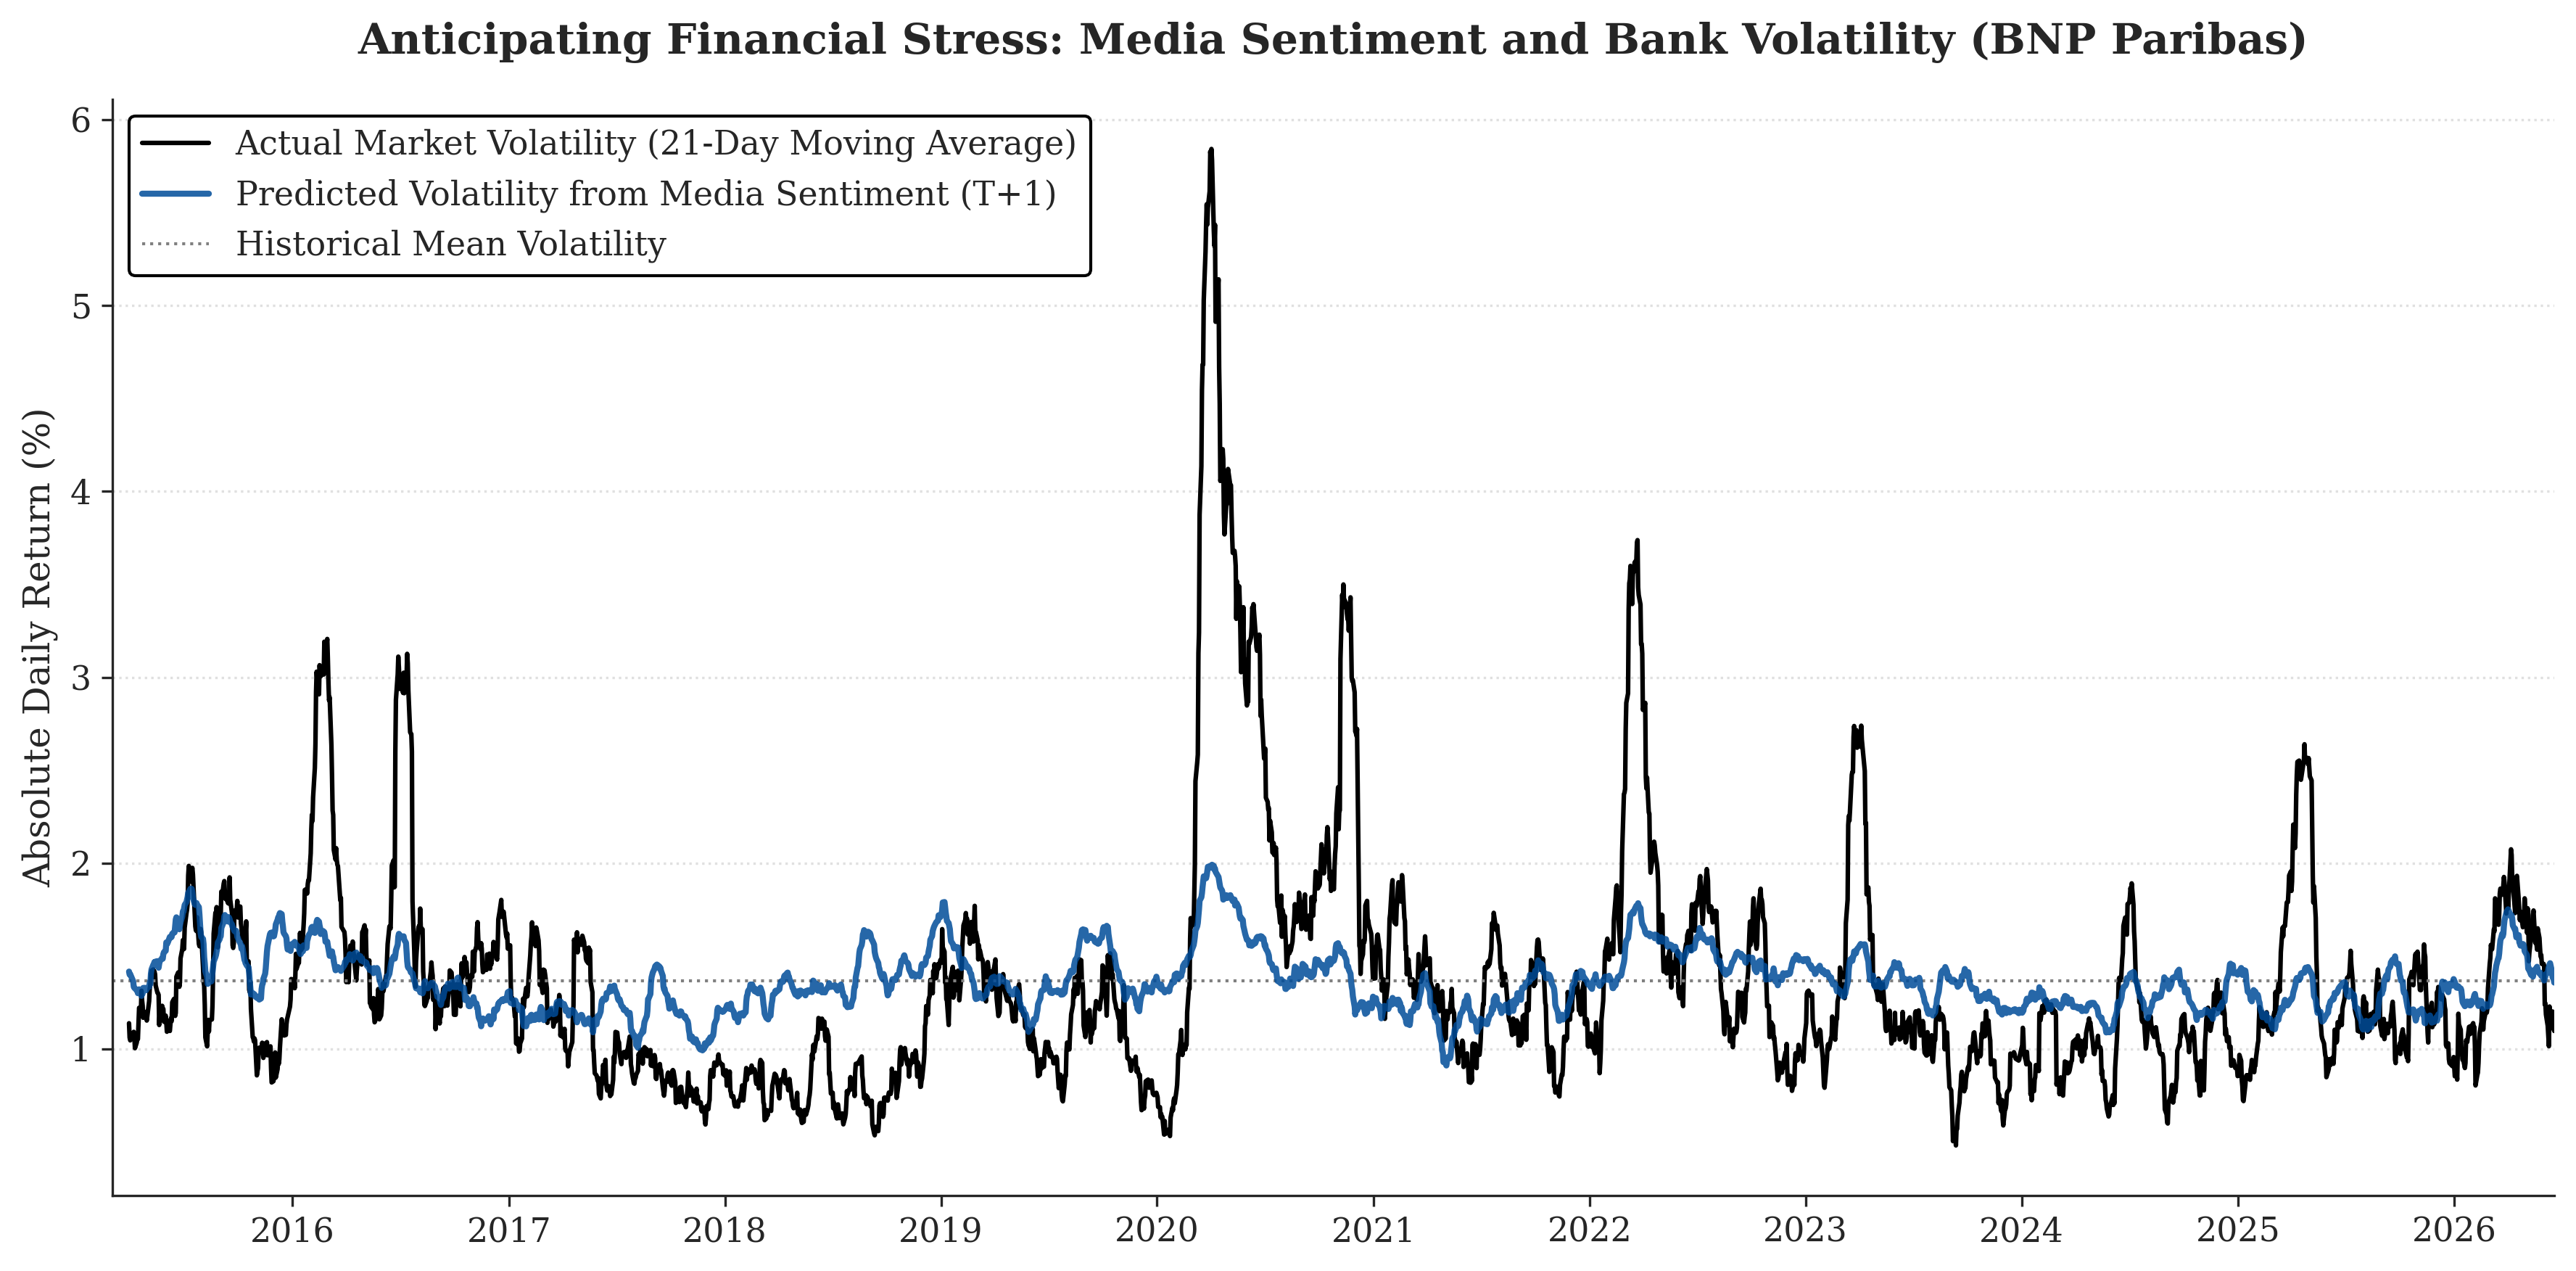

In [8]:
# ==============================================================================
# CELLULE 7 : VISUALISATION ACADÉMIQUE DE LA VOLATILITÉ (BNP PARIBAS)
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import StandardScaler
import os

# 1. Configuration Académique (Times New Roman)
sns.set_style("ticks")
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 300
})

# 2. Re-calcul rapide du modèle pour BNP Paribas (Cible = Volatilité)
target_ticker = 'BNP.PA'
region = 'France'
keywords = ['finance_banks', 'finance_systemic_risk', 'finance_central_banks']

# Préparation GDELT
df_region = df_geo_daily[df_geo_daily['region_key'] == region].set_index('period')
target_cols = [c for c in df_region.columns if any(kw in c for kw in keywords) and c.startswith('sent_bin_weight_')]
X_gdelt = df_region[target_cols].copy()
X_gdelt_bday = X_gdelt.resample('B').mean().ffill()
X_stat = strict_stationarize_daily(X_gdelt_bday)

# Préparation Marché
stock = yf.Ticker(target_ticker)
y_data = stock.history(start=start_date.strftime('%Y-%m-%d'), end="2026-07-01", interval="1d")['Close']
if y_data.index.tz is not None:
    y_data.index = y_data.index.tz_localize(None)

# RENDEMENT ABSOLU (VOLATILITÉ) décalé à T+1
y_returns = y_data.pct_change().dropna() * 100
y_target = y_returns.abs().shift(-1).dropna() 

X_aligned, y_aligned = X_stat.align(y_target, join='inner', axis=0)
X_scaled = pd.DataFrame(StandardScaler().fit_transform(X_aligned), columns=X_aligned.columns, index=X_aligned.index)
X_scaled = sm.add_constant(X_scaled)

# Modèle OLS
model = sm.OLS(y_aligned, X_scaled).fit()
y_predicted = model.fittedvalues

# 3. LISSAGE POUR LA VISUALISATION (Moyenne mobile 21 jours = 1 mois boursier)
# Cela permet de voir les "régimes" de volatilité plutôt que le bruit quotidien
window = 21 
actual_vol_smooth = y_aligned.rolling(window=window).mean()
predicted_vol_smooth = y_predicted.rolling(window=window).mean()

# 4. Tracé du graphique
fig, ax = plt.subplots(figsize=(12, 6))

# Ligne 1 : Volatilité Réelle (Noir)
ax.plot(actual_vol_smooth.index, actual_vol_smooth.values, 
        label=f'Actual Market Volatility (21-Day Moving Average)', 
        color='black', linewidth=1.5, zorder=2)

# Ligne 2 : Volatilité Prédite par GDELT (Bleu profond)
ax.plot(predicted_vol_smooth.index, predicted_vol_smooth.values, 
        label=f'Predicted Volatility from Media Sentiment (T+1)', 
        color='#004c99', linestyle='-', linewidth=2, alpha=0.85, zorder=3)

# 5. Habillage
ax.set_ylabel('Absolute Daily Return (%)')
ax.set_title('Anticipating Financial Stress: Media Sentiment and Bank Volatility (BNP Paribas)', pad=15, fontweight='bold')

ax.set_xlim(actual_vol_smooth.index.min(), actual_vol_smooth.index.max())
ax.axhline(actual_vol_smooth.mean(), color='gray', linestyle=':', linewidth=1, label='Historical Mean Volatility')

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate(rotation=0, ha='center')

ax.legend(loc='upper left', frameon=True, edgecolor='black', facecolor='white', framealpha=1)
ax.grid(True, which='major', axis='y', linestyle=':', alpha=0.6)
sns.despine()

# Sauvegarde PDF
os.makedirs('./latex_tables', exist_ok=True)
plt.savefig('./latex_tables/Volatility_Prediction_BNP.pdf', format='pdf', bbox_inches='tight')

plt.tight_layout()
plt.show()